<a href="https://colab.research.google.com/github/DulaniDeSilva/Computer-Vision/blob/main/vehicle_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import glob
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [ ]:
vehicle_images_path = '/kaggle/input/vehicle-detection-image-set/data/vehicles'
non_vehicle_images_path = '/kaggle/input/vehicle-detection-image-set/data/non-vehicles'

# Function to get image paths from a directory
def get_image_paths_from_directory(directory_path):
    return glob.glob(os.path.join(directory_path, '*'))

# Get image paths for vehicles and non-vehicles
vehicle_image_paths = get_image_paths_from_directory(vehicle_images_path)
non_vehicle_image_paths = get_image_paths_from_directory(non_vehicle_images_path)

# Shuffle the paths
random.shuffle(vehicle_image_paths)
random.shuffle(non_vehicle_image_paths)

# Function to split data into train, test, and val sets
def split_dataset(image_paths, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    assert train_ratio + val_ratio + test_ratio == 1.0, "Ratios must sum to 1.0"

    total_images = len(image_paths)
    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    train_paths = image_paths[:train_end]
    val_paths = image_paths[train_end:val_end]
    test_paths = image_paths[val_end:]

    return train_paths, val_paths, test_paths

# Split vehicle and non-vehicle datasets
vehicle_train, vehicle_val, vehicle_test = split_dataset(vehicle_image_paths)
non_vehicle_train, non_vehicle_val, non_vehicle_test = split_dataset(non_vehicle_image_paths)

# Print the number of images in each split
print(f"Vehicle images: Train = {len(vehicle_train)}, Val = {len(vehicle_val)}, Test = {len(vehicle_test)}")
print(f"Non-Vehicle images: Train = {len(non_vehicle_train)}, Val = {len(non_vehicle_val)}, Test = {len(non_vehicle_test)}")

Vehicle images: Train = 6154, Val = 1318, Test = 1320
Non-Vehicle images: Train = 6277, Val = 1345, Test = 1346


In [ ]:
from concurrent.futures import ThreadPoolExecutor

# Initialize the HOG descriptor once
hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

hog_fine_grained = cv2.HOGDescriptor(
    _winSize=(64, 64),         # Window size
    _blockSize=(8, 8),         # Smaller block size
    _blockStride=(4, 4),       # Smaller block stride
    _cellSize=(4, 4),          # Smaller cell size
    _nbins=9                   # Number of orientation bins
)

hog_coarse = cv2.HOGDescriptor(
    _winSize=(128, 128),       # Larger window size
    _blockSize=(32, 32),       # Larger block size
    _blockStride=(16, 16),     # Larger block stride
    _cellSize=(16, 16),        # Larger cell size
    _nbins=9                   # Number of orientation bins
)

# Function to extract HOG features from an image
def extract_hog_features(image, descriptor=hog):
    return descriptor.compute(image)

# Function to process a single image path and return the features and label
def process_image(path, label, descriptor=hog):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
    img = cv2.resize(img, (64, 64))  # Resize image to a standard size
    hog_features = extract_hog_features(img, descriptor)
    return hog_features.flatten(), label

# Function to prepare features and labels with parallel processing
def prepare_data(image_paths, label, descriptor=hog):
    with ThreadPoolExecutor() as executor:
        results = executor.map(lambda p: process_image(p, label, descriptor), image_paths)
    features, labels = zip(*results)
    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int32)

In [ ]:
def evaluate_model(true_labels, predictions, dataset_name=''):
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predictions)
    print(f"Confusion Matrix for {dataset_name} Set:")
    print(conf_matrix)

    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Vehicle', 'Vehicle'],
                yticklabels=['Non-Vehicle', 'Vehicle'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.show()

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f"{dataset_name} Accuracy: {accuracy * 100:.2f}%")

    # Calculate precision, recall, F1 score
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    # Calculate specificity
    TN = conf_matrix[0, 0]
    FP = conf_matrix[0, 1]
    specificity = TN / (TN + FP)

    print(f"Precision: {precision:.2f}")
    print(f"Recall (Sensitivity): {recall:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Additional metrics
    FPR = FP / (FP + TN)
    FN = conf_matrix[1, 0]
    TP = conf_matrix[1, 1]
    FNR = FN / (TP + FN)

    print(f"False Positive Rate (FPR): {FPR:.2f}")
    print(f"False Negative Rate (FNR): {FNR:.2f}")

In [ ]:
def evaluate_model(true_labels, predictions, dataset_name=''):
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predictions)
    print(f"Confusion Matrix for {dataset_name} Set:")
    print(conf_matrix)

    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Vehicle', 'Vehicle'],
                yticklabels=['Non-Vehicle', 'Vehicle'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.show()

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f"{dataset_name} Accuracy: {accuracy * 100:.2f}%")

    # Calculate precision, recall, F1 score
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    # Calculate specificity
    TN = conf_matrix[0, 0]
    FP = conf_matrix[0, 1]
    specificity = TN / (TN + FP)

    print(f"Precision: {precision:.2f}")
    print(f"Recall (Sensitivity): {recall:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Additional metrics
    FPR = FP / (FP + TN)
    FN = conf_matrix[1, 0]
    TP = conf_matrix[1, 1]
    FNR = FN / (TP + FN)

    print(f"False Positive Rate (FPR): {FPR:.2f}")
    print(f"False Negative Rate (FNR): {FNR:.2f}")

In [ ]:
# Create and train the SVM model
svm_linear = cv2.ml.SVM_create()
svm_linear.setKernel(cv2.ml.SVM_LINEAR)
svm_linear.setType(cv2.ml.SVM_C_SVC)
svm_linear.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6))

# Create and train the SVM model
svm_poly_3 = cv2.ml.SVM_create()
svm_poly_3.setKernel(cv2.ml.SVM_POLY)
svm_poly_3.setDegree(3)  # Polynomial degree
svm_poly_3.setGamma(0.5)  # Gamma value
svm_poly_3.setCoef0(1)   # Coefficient 0
svm_poly_3.setType(cv2.ml.SVM_C_SVC)
svm_poly_3.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6))

# Create and train the SVM model with RBF kernel
svm_rbf = cv2.ml.SVM_create()
svm_rbf.setKernel(cv2.ml.SVM_RBF)
svm_rbf.setGamma(0.1)  # Gamma value for RBF kernel
svm_rbf.setC(1.0)      # Regularization parameter
svm_rbf.setType(cv2.ml.SVM_C_SVC)
svm_rbf.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6))

def train_and_evaluate_svm(train_features, train_labels, val_features, val_labels, test_features, test_labels):
    """
    Train and evaluate an SVM model with linear, polynomial, and RBF kernels and parameters.

    Args:
        train_features: Training feature data.
        train_labels: Training labels.
        val_features: Validation feature data.
        val_labels: Validation labels.
        test_features: Test feature data.
        test_labels: Test labels.
    """

    ### LINEAR KERNEL

    # Train the SVM
    svm_linear.train(train_features, cv2.ml.ROW_SAMPLE, train_labels)

    # Validate the model
    _, val_predictions = svm_linear.predict(val_features)
    val_predictions = val_predictions.astype(int)  # Ensure predictions are integer type

    evaluate_model(val_labels, val_predictions, dataset_name='Validation')

    # Test the model
    _, test_predictions = svm_linear.predict(test_features)
    test_predictions = test_predictions.astype(int)  # Ensure predictions are integer type

    evaluate_model(test_labels, test_predictions, dataset_name='Test')

    ### POLYNOMIAL KERNEL

    # Train the SVM
    svm_poly_3.train(train_features, cv2.ml.ROW_SAMPLE, train_labels)

    # Validate the model
    _, val_predictions = svm_poly_3.predict(val_features)
    val_predictions = val_predictions.astype(int)  # Ensure predictions are integer type

    evaluate_model(val_labels, val_predictions, dataset_name='Validation')

    # Test the model
    _, test_predictions = svm_poly_3.predict(test_features)
    test_predictions = test_predictions.astype(int)  # Ensure predictions are integer type

    evaluate_model(test_labels, test_predictions, dataset_name='Test')

    ### RBF KERNEL

    # Train the SVM
    svm_rbf.train(train_features, cv2.ml.ROW_SAMPLE, train_labels)

    # Validate the model
    _, val_predictions = svm_rbf.predict(val_features)
    val_predictions = val_predictions.astype(int)  # Ensure predictions are integer type

    evaluate_model(val_labels, val_predictions, dataset_name='Validation')

    # Test the model
    _, test_predictions = svm_rbf.predict(test_features)
    test_predictions = test_predictions.astype(int)  # Ensure predictions are integer type

    evaluate_model(test_labels, test_predictions, dataset_name='Test')

Confusion Matrix for Validation Set:
[[ 982  363]
 [ 247 1071]]


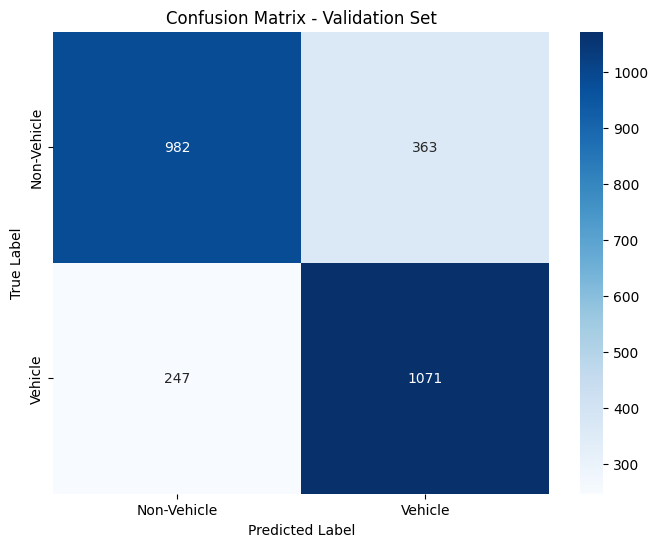

Validation Accuracy: 77.09%
Precision: 0.75
Recall (Sensitivity): 0.81
Specificity: 0.73
F1 Score: 0.78
False Positive Rate (FPR): 0.27
False Negative Rate (FNR): 0.19
Confusion Matrix for Test Set:
[[ 984  362]
 [ 247 1073]]


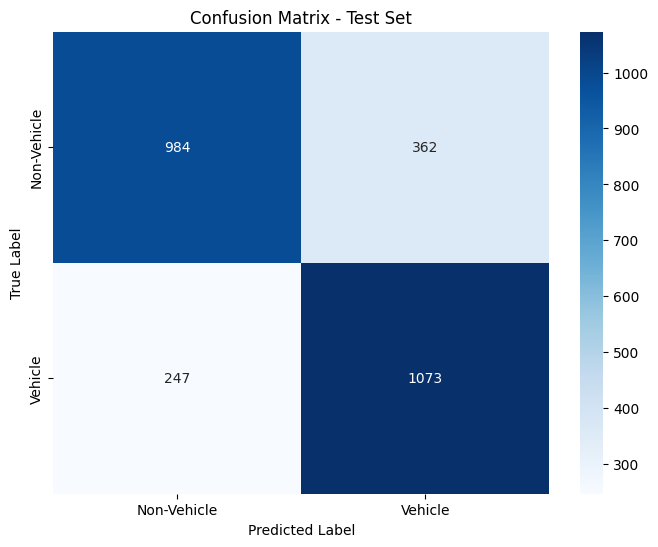

Test Accuracy: 77.16%
Precision: 0.75
Recall (Sensitivity): 0.81
Specificity: 0.73
F1 Score: 0.78
False Positive Rate (FPR): 0.27
False Negative Rate (FNR): 0.19
Confusion Matrix for Validation Set:
[[1232  113]
 [  43 1275]]


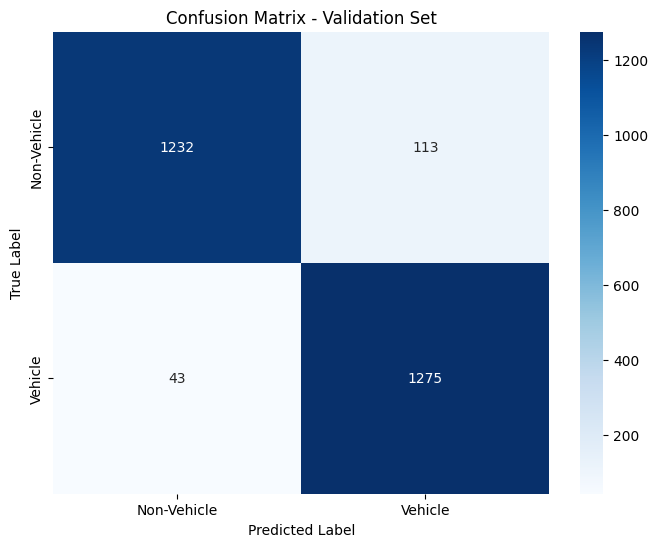

Validation Accuracy: 94.14%
Precision: 0.92
Recall (Sensitivity): 0.97
Specificity: 0.92
F1 Score: 0.94
False Positive Rate (FPR): 0.08
False Negative Rate (FNR): 0.03
Confusion Matrix for Test Set:
[[1215  131]
 [  44 1276]]


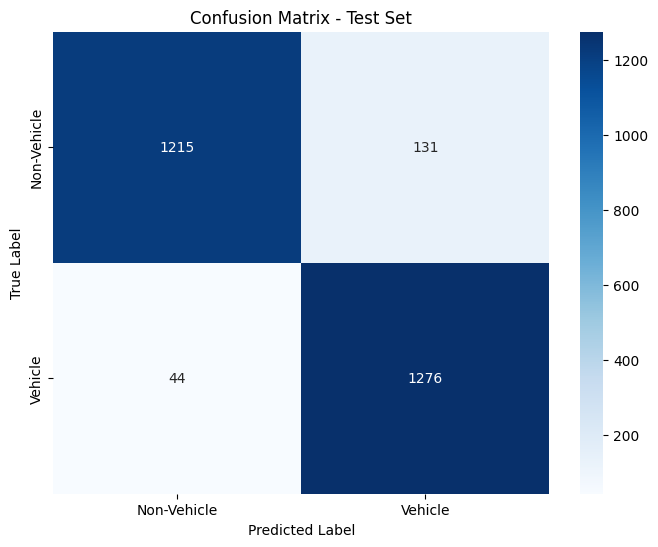

Test Accuracy: 93.44%
Precision: 0.91
Recall (Sensitivity): 0.97
Specificity: 0.90
F1 Score: 0.94
False Positive Rate (FPR): 0.10
False Negative Rate (FNR): 0.03
Confusion Matrix for Validation Set:
[[1312   33]
 [  46 1272]]


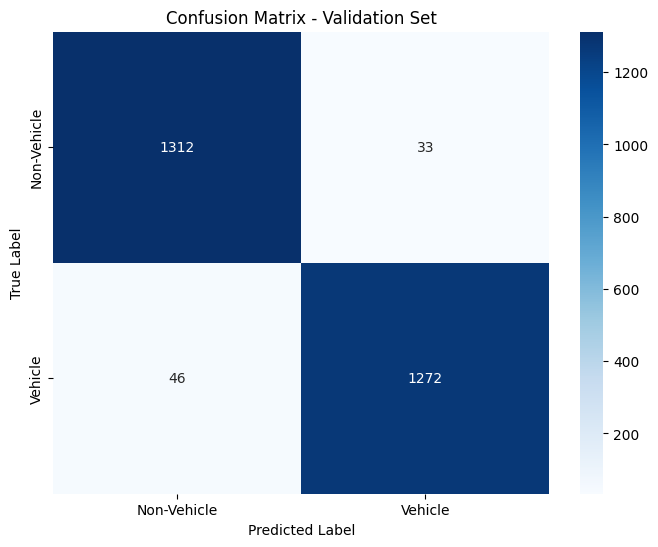

Validation Accuracy: 97.03%
Precision: 0.97
Recall (Sensitivity): 0.97
Specificity: 0.98
F1 Score: 0.97
False Positive Rate (FPR): 0.02
False Negative Rate (FNR): 0.03
Confusion Matrix for Test Set:
[[1322   24]
 [  50 1270]]


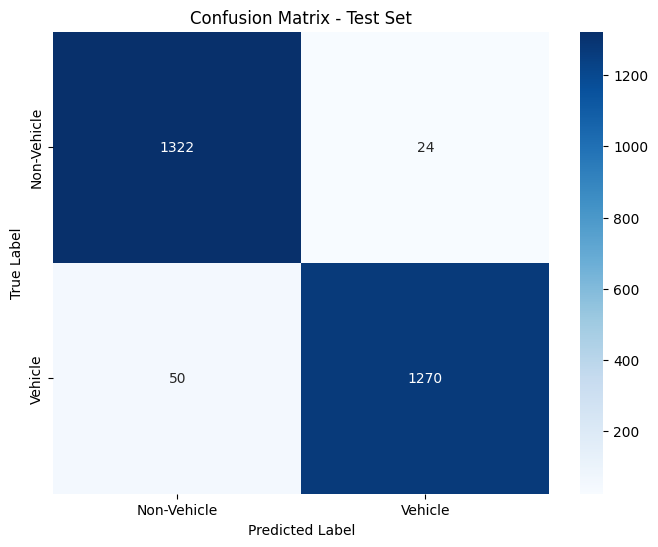

Test Accuracy: 97.22%
Precision: 0.98
Recall (Sensitivity): 0.96
Specificity: 0.98
F1 Score: 0.97
False Positive Rate (FPR): 0.02
False Negative Rate (FNR): 0.04


In [ ]:
# HOG

# Prepare the training data
train_features_vehicle, train_labels_vehicle = prepare_data(vehicle_train, 1)
train_features_non_vehicle, train_labels_non_vehicle = prepare_data(non_vehicle_train, 0)

train_features = np.vstack((train_features_vehicle, train_features_non_vehicle))
train_labels = np.hstack((train_labels_vehicle, train_labels_non_vehicle))

# Save the feature vectors and labels
np.save('train_features.npy', train_features)
np.save('train_labels.npy', train_labels)

# Option to use a subset of the training data
def subset_data(features, labels, subset_ratio=1.0):
    if subset_ratio < 1.0:
        num_samples = int(len(features) * subset_ratio)
        features, labels = features[:num_samples], labels[:num_samples]
    return features, labels

# Load and optionally subset the training data
train_features = np.load('train_features.npy')
train_labels = np.load('train_labels.npy')

# Control the percentage of data to be used in training
subset_ratio = 1.0  # Use 80% of the training data
train_features, train_labels = subset_data(train_features, train_labels, subset_ratio)

# Prepare the validation data
val_features_vehicle, val_labels_vehicle = prepare_data(vehicle_val, 1)
val_features_non_vehicle, val_labels_non_vehicle = prepare_data(non_vehicle_val, 0)

val_features = np.vstack((val_features_vehicle, val_features_non_vehicle))
val_labels = np.hstack((val_labels_vehicle, val_labels_non_vehicle))

# Prepare the testing data
test_features_vehicle, test_labels_vehicle = prepare_data(vehicle_test, 1)
test_features_non_vehicle, test_labels_non_vehicle = prepare_data(non_vehicle_test, 0)

test_features = np.vstack((test_features_vehicle, test_features_non_vehicle))
test_labels = np.hstack((test_labels_vehicle, test_labels_non_vehicle))

train_and_evaluate_svm(train_features, train_labels, val_features, val_labels, test_features, test_labels)

Features for image 6.jpg: [[0.0751004  0.00582593 0.00090248 ... 0.16315953 0.09941754 0.13008304]]
Model: Poly 3, Image: 6.jpg, Prediction: 0
Features for image 5.jpg: [[0.10520887 0.1020528  0.06369074 ... 0.20322819 0.21484308 0.22129099]]
Model: Poly 3, Image: 5.jpg, Prediction: 1
Features for image 8.jpg: [[0.04387954 0.03162492 0.09463378 ... 0.04491069 0.00827339 0.03854824]]
Model: Poly 3, Image: 8.jpg, Prediction: 0
Features for image 1.jpg: [[0.0728033  0.2230161  0.24531864 ... 0.29900435 0.18222149 0.08139242]]
Model: Poly 3, Image: 1.jpg, Prediction: 0
Features for image 7.jpg: [[0.25545904 0.08612032 0.0469205  ... 0.19338019 0.15046535 0.2586926 ]]
Model: Poly 3, Image: 7.jpg, Prediction: 0
Features for image 4.jpg: [[0.03302215 0.05519855 0.0612544  ... 0.05123262 0.09334137 0.21845756]]
Model: Poly 3, Image: 4.jpg, Prediction: 1
Features for image 3.jpg: [[0.10880262 0.23091936 0.23091936 ... 0.03599724 0.07251568 0.24073687]]
Model: Poly 3, Image: 3.jpg, Prediction: 1

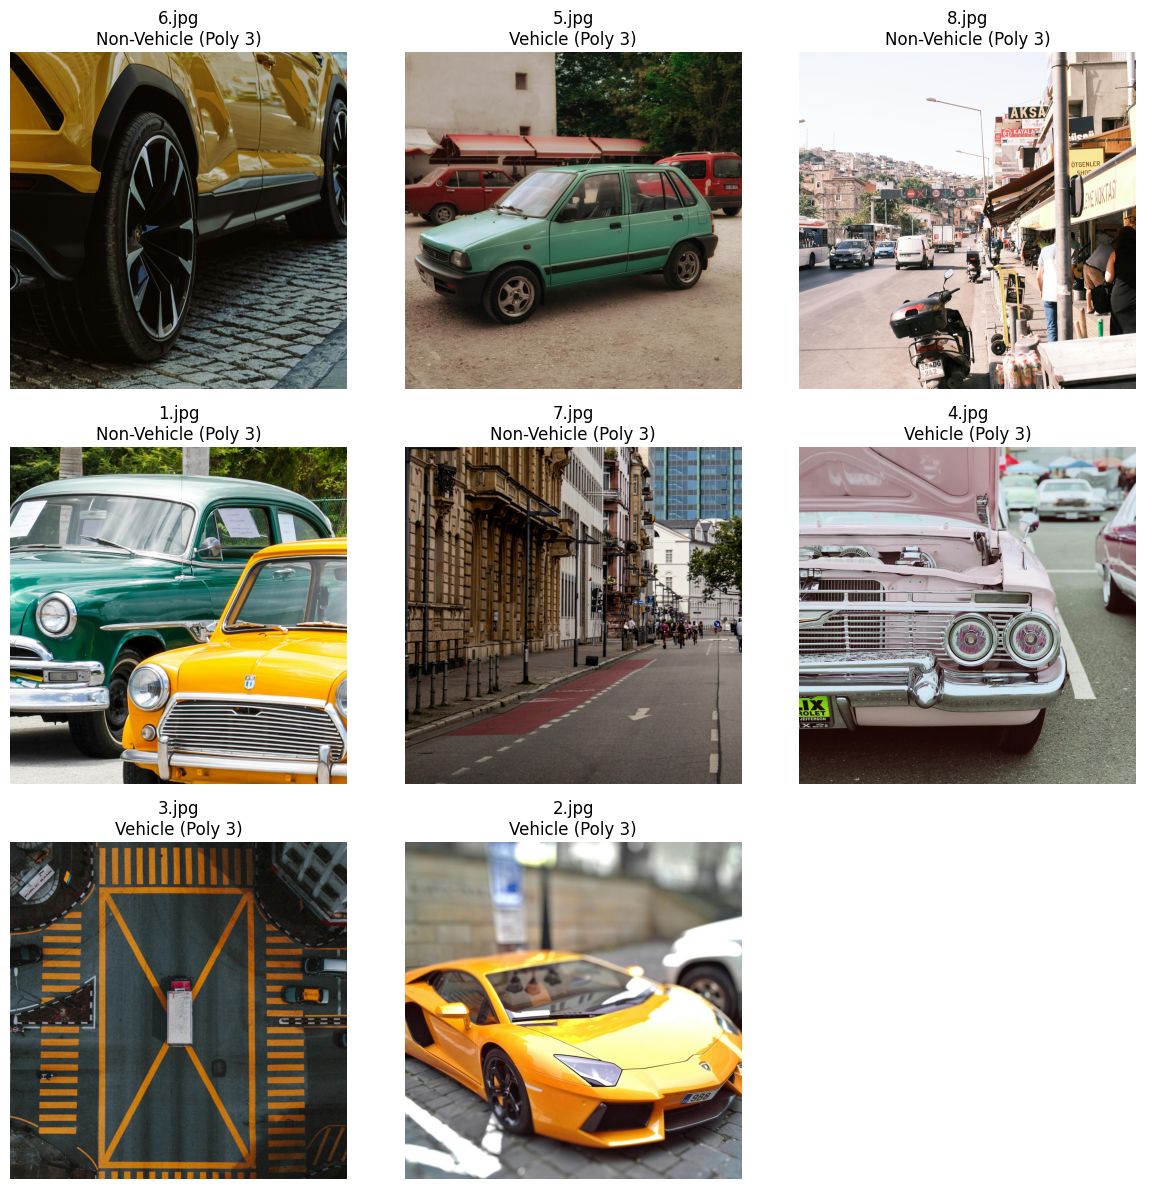

In [ ]:
predict_folder = '/kaggle/input/prediction-data-set-for-vehicle-svm/predict'

def predict_images(predict_folder):
    image_paths = get_image_paths_from_directory(predict_folder)
    results = {}

    for path in image_paths:
        try:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            hog_features = extract_hog_features(img).flatten()

            # Ensure that hog_features is of type np.float32
            hog_features = hog_features.astype(np.float32).reshape(1, -1)

            print(f"Features for image {os.path.basename(path)}: {hog_features}")

            # Check if the number of features matches the model's expectation
            if hog_features.shape[1] != svm_poly_3.getVarCount():
                print(f"Feature dimension mismatch for image {os.path.basename(path)}. Expected {svm_poly_3.getVarCount()}, got {hog_features.shape[1]}.")
                continue

            try:
                _, prediction = svm_poly_3.predict(hog_features)
                prediction = int(prediction[0, 0])
                print(f"Model: Poly 3, Image: {os.path.basename(path)}, Prediction: {prediction}")
                results[path] = ('Poly 3', prediction)
            except cv2.error as e:
                print(f"Error predicting with Poly 3 model for image {os.path.basename(path)}: {e}")

        except Exception as e:
            print(f"Error processing image {os.path.basename(path)}: {e}")

    return results

# Predict images in the predict folder
predictions = predict_images(predict_folder)

# Prepare to plot images and their predictions
image_paths = list(predictions.keys())
n_images = len(image_paths)
n_cols = 3
n_rows = (n_images + n_cols - 1) // n_cols  # Calculate number of rows needed

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))  # Adjust size based on number of images
axes = axes.flatten()

for i, image_path in enumerate(image_paths):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Read the original image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    label = 'Vehicle' if predictions[image_path][1] == 1 else 'Non-Vehicle'
    print(f"Image: {os.path.basename(image_path)}, Model: Poly 3, Prediction: {label}")
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{os.path.basename(image_path)}\n{label} (Poly 3)")
    axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Features for image 6.jpg: [[0.0751004  0.00582593 0.00090248 ... 0.16315953 0.09941754 0.13008304]]
Model: RBF, Image: 6.jpg, Prediction: 0
Features for image 5.jpg: [[0.10520887 0.1020528  0.06369074 ... 0.20322819 0.21484308 0.22129099]]
Model: RBF, Image: 5.jpg, Prediction: 0
Features for image 8.jpg: [[0.04387954 0.03162492 0.09463378 ... 0.04491069 0.00827339 0.03854824]]
Model: RBF, Image: 8.jpg, Prediction: 0
Features for image 1.jpg: [[0.0728033  0.2230161  0.24531864 ... 0.29900435 0.18222149 0.08139242]]
Model: RBF, Image: 1.jpg, Prediction: 1
Features for image 7.jpg: [[0.25545904 0.08612032 0.0469205  ... 0.19338019 0.15046535 0.2586926 ]]
Model: RBF, Image: 7.jpg, Prediction: 0
Features for image 4.jpg: [[0.03302215 0.05519855 0.0612544  ... 0.05123262 0.09334137 0.21845756]]
Model: RBF, Image: 4.jpg, Prediction: 0
Features for image 3.jpg: [[0.10880262 0.23091936 0.23091936 ... 0.03599724 0.07251568 0.24073687]]
Model: RBF, Image: 3.jpg, Prediction: 0
Features for image 2

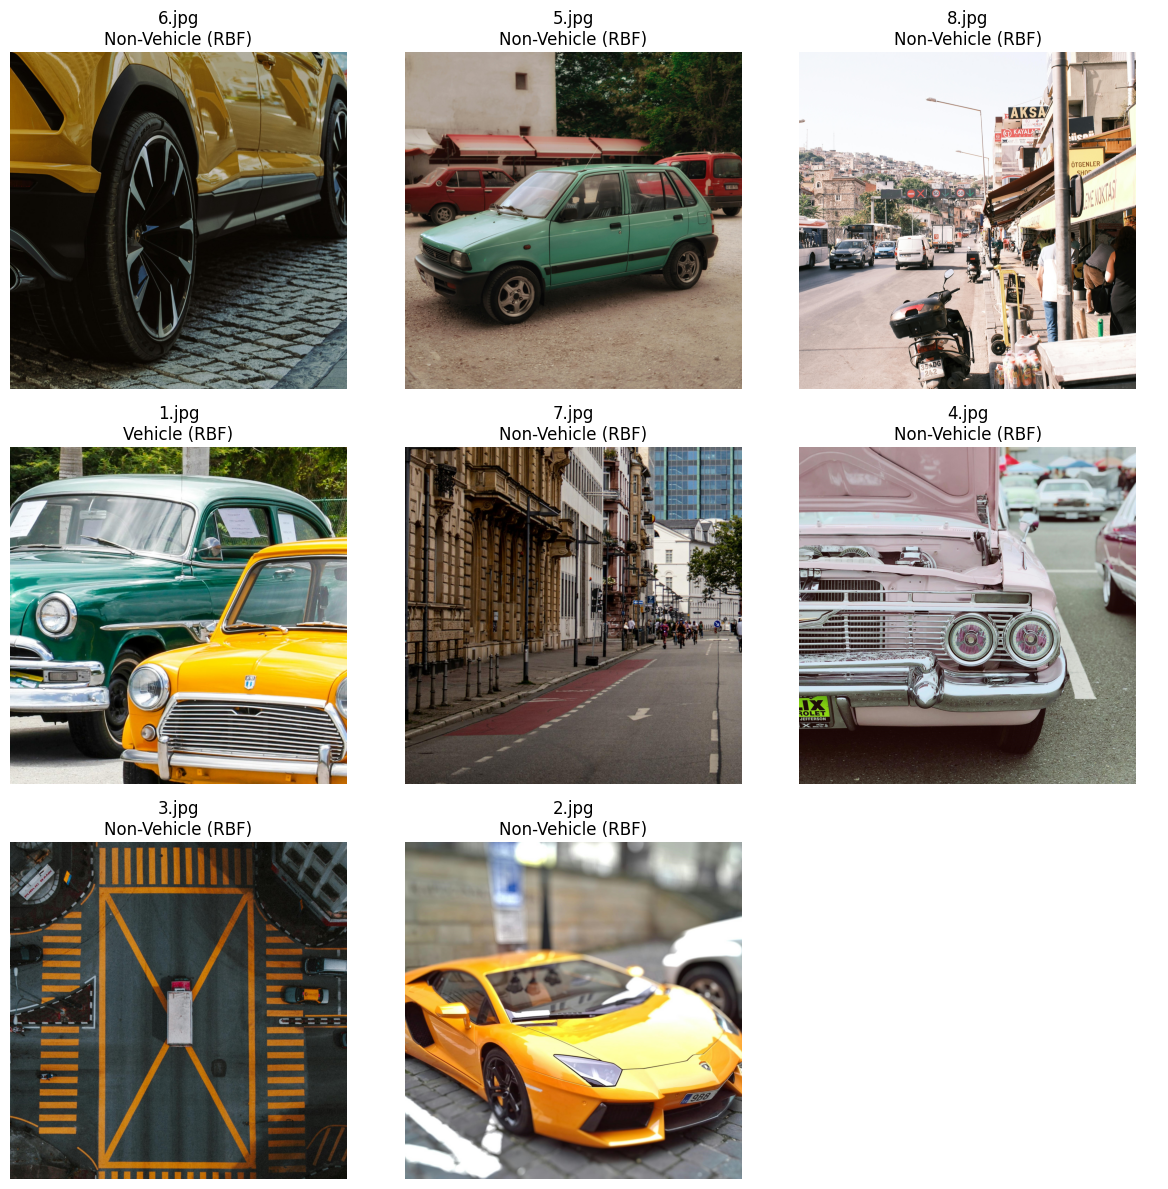

In [ ]:
predict_folder = '/kaggle/input/prediction-data-set-for-vehicle-svm/predict'

def predict_images(predict_folder):
    image_paths = get_image_paths_from_directory(predict_folder)
    results = {}

    for path in image_paths:
        try:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            hog_features = extract_hog_features(img).flatten()

            # Ensure that hog_features is of type np.float32
            hog_features = hog_features.astype(np.float32).reshape(1, -1)

            print(f"Features for image {os.path.basename(path)}: {hog_features}")

            # Check if the number of features matches the model's expectation
            if hog_features.shape[1] != svm_rbf.getVarCount():
                print(f"Feature dimension mismatch for image {os.path.basename(path)}. Expected {svm_rbf.getVarCount()}, got {hog_features.shape[1]}.")
                continue

            try:
                _, prediction = svm_rbf.predict(hog_features)
                prediction = int(prediction[0, 0])
                print(f"Model: RBF, Image: {os.path.basename(path)}, Prediction: {prediction}")
                results[path] = ('RBF', prediction)
            except cv2.error as e:
                print(f"Error predicting with RBF model for image {os.path.basename(path)}: {e}")

        except Exception as e:
            print(f"Error processing image {os.path.basename(path)}: {e}")

    return results

# Predict images in the predict folder
predictions = predict_images(predict_folder)

# Prepare to plot images and their predictions
image_paths = list(predictions.keys())
n_images = len(image_paths)
n_cols = 3
n_rows = (n_images + n_cols - 1) // n_cols  # Calculate number of rows needed

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))  # Adjust size based on number of images
axes = axes.flatten()

for i, image_path in enumerate(image_paths):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Read the original image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    label = 'Vehicle' if predictions[image_path][1] == 1 else 'Non-Vehicle'
    print(f"Image: {os.path.basename(image_path)}, Model: RBF, Prediction: {label}")
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{os.path.basename(image_path)}\n{label} (RBF)")
    axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()